In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from datetime import date, datetime, timedelta, timezone
from astroquery.jplhorizons import Horizons
import pandas as pd
import xarray as xr
from tqdm import tqdm
from matplotlib.patches import Rectangle
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, get_body, get_sun
from astropy.time import Time

ephempath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool'

In [2]:
'''
This is a sandbox for a tool that will ingest an observatory location and datetime, and return the RA/DEC 
pointing constraints for observing during morning twilight.
''';

### Functions bank

In [153]:
def read_solar_ephemeris(datestr=None):
    '''
    Read pre-generated lookup table of solar ephemerides from Keck II. 
    User can input an optional date string (YYY-MM-DD) to pull ephemerides
    from this date; otherwise, the code pulls ephemerides from today.
    '''
    
    # Parse date if given by user
    if datestr is not None:
        date = datetime.strptime(datestr, '%Y-%m-%d')
        year = date.strftime('%Y')
    
    # Otherwise, use today's date
    else:
        now = datetime.now()
        date = now.strftime('%Y-%m-%d')
        year = now.strftime('%Y')
        
        
    # Read in solar ephemeris table from matching year
    ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{year}.csv')
    
    
    # Identify row of ephemeris table that matches date
    try: 
        
        ix = ephem.index[ephem['Date'] == today_date].tolist()

        try: 
            assert len(ix)==1
            ix = ix[0]
        except: 
            print(f'Multiple rows for the same date. Something went wrong for the {date} ephemeris!')
            return 0

    except: 
        print(f'Solar ephemeris not available for {date}. Go make one.')
        return 0
    
    
    # Parse sunrise/sunset parameters from matching date
    sunset_UTC = ephem['sunset_UTC'][ix]
    sunset_az = ephem['sunset_az'][ix]
    sunset_el = ephem['sunset_el'][ix]
    sunset_ra = ephem['sunset_ra'][ix]
    sunset_dec = ephem['sunset_dec'][ix]
    sunset_sidereal = ephem['sunset_sidereal'][ix]
    
    sunrise_UTC = ephem['sunrise_UTC'][ix]
    sunrise_az = ephem['sunrise_az'][ix]
    sunrise_el = ephem['sunrise_el'][ix]
    sunrise_ra = ephem['sunrise_ra'][ix]
    sunrise_dec = ephem['sunrise_dec'][ix]
    sunrise_sidereal = ephem['sunrise_sidereal'][ix]
    
    return sunset_UTC, sunset_az, sunset_el, sunset_ra, sunset_dec, sunset_sidereal, \
            sunrise_UTC, sunrise_az, sunrise_el, sunrise_ra, sunrise_dec, sunrise_sidereal
    


def keckII_pointing_limits(az, el):
    '''
    Returns if given az, el is within Keck II telescope pointing constraints.
    See documentation: https://www2.keck.hawaii.edu/inst/common/TelLimits.html
    '''
    
    # Check against nasmyth deck pointing limit
    if (az >= 185.3) and (az <= 332.8):
        if el >= 36.8:
            return True
        else:
            return False
        
    # Check against shutter vignetting
    else:
        if el >= 18.0:
            return True
        else:
            return False
        
        
def twilight_pointing_limits(az, sun_az, az_sep=45.):
    '''
    Check if telescope az is >=45˚ from the sun. (az, sun_az units in degrees)
    Since telescope shutters are vertical, el angle does NOT matter.
    '''

    # Find difference between sun, telescope az angles
    if az > 180.:
        az = az - 360.

    if sun_az > 180.:
        sun_az = sun_az - 360.
    
    az_diff = np.abs(az-sun_az)
    print(az_diff)
                
    
    # Check if input az obeys twilight pointing constraints
    if az_diff < az_sep: 
        return False
    else: 
        return True
    


    
def query_JPL_horizons(start, end):
    '''
    start: datetime object, year month day 03:00:00
    start: datetime object, year month day 18:00:00
    '''

    # Set epoch to query
    epoch =  {'start':start.strftime('%Y-%m-%d %H:%M:%S'), 'stop':end.strftime('%Y-%m-%d %H:%M:%S'), 'step':'1m'}

    
    # Send query
    obj = Horizons(id='sun', location='T17', epochs=epoch) # t17 = Keck II
    result = obj.ephemerides(skip_daylight=True)

    if not (result['solar_presence'][0]=='C') & (result['solar_presence'][-1]=='C'):
        print('FUCKED UP!', epoch)

        
    # Extract sunset params
    sunset_time = result['datetime_str'][0] # datetime string, e.g. '2025-Jan-01 04:04'
    sunset_az = result['AZ'][0] # deg
    sunset_el = result['EL'][0] # deg
    sunset_ra = result['RA_app'][0] # deg
    sunset_dec = result['DEC_app'][0] # deg
    sunset_sidereal = result['siderealtime'][0] # hours

    
    # Extract sunrise params
    sunrise_time = result['datetime_str'][-1] # datetime string, e.g. '2025-Jan-01 04:04'
    sunrise_az = result['AZ'][-1] # deg
    sunrise_el = result['EL'][-1] # deg
    sunrise_ra = result['RA_app'][-1] # deg
    sunrise_dec = result['DEC_app'][-1] # deg
    sunrise_sidereal = result['siderealtime'][-1] # hours

    
    # Return all params as single row
    return start.strftime('%Y-%m-%d'), sunset_time, sunset_az, sunset_el, sunset_ra, sunset_dec, \
            sunset_sidereal, sunrise_time, sunrise_az, sunrise_el, sunrise_ra, sunrise_dec, sunrise_sidereal


# Func-ify plot

def make_azel_plot(sunset_UTC, sunset_az, sunrise_UTC, sunrise_az, obj_az, obj_el, trace_times, obj_label='Target'):
    
    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(5, 7), subplot_kw={'projection': 'polar'}, layout='constrained')
    plt.tight_layout()
    
    ax.set_rmax(0.)
    ax.set_rmin(90.)
    ax.grid(True)
    ax.set_theta_zero_location('N')

    ax.annotate('N', (np.deg2rad(10.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('S', (np.deg2rad(185.), -12.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('W', (np.deg2rad(85.), -14.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
    ax.annotate('E', (np.deg2rad(275.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')

    # Calculate Keck II pointing limits
    linspace_az = np.linspace(0., 2.*np.pi, 100)

    tel_constraints_el = np.full_like(linspace_az, 18.0)
    tel_constraints_el[(linspace_az >= np.deg2rad(185.3)) & (linspace_az <= np.deg2rad(332.8))] = 36.8

    horizon_el = np.zeros_like(linspace_az)
    
    # Plot Keck II pointing limits
    ax.plot(linspace_az, tel_constraints_el, ls='--', color='gray')
    ax.fill_between(linspace_az, horizon_el, tel_constraints_el, color='gray', alpha=0.3, label='Keck II limits')
    
    # Calculate twilight pointing constraints
    
    az_lolim = sunrise_az - 45.
    az_uplim = sunrise_az + 45.

    if az_lolim < 0:
        az_lolim += 360.
    if az_uplim > 360.:
        az_uplim %= 360.

    twi_constraints_el = np.full_like(linspace_az, 0.0)
    twi_constraints_el[(linspace_az > np.deg2rad(az_lolim)) & (linspace_az < np.deg2rad(az_uplim))] = 90.


    # Plot twilight pointing constraints
    ax.scatter(np.deg2rad(sunrise_az), 3., marker='*', color='r', edgecolor='k', s=200, label=f'Sunrise location ({sunrise_UTC} UTC)')

    ax.fill_between(linspace_az, horizon_el, twi_constraints_el, color='red', alpha=0.3, 
                label=f'Sunrise limits ({az_lolim:0.0f} < az < {az_uplim:0.0f})')
    
    # Find timestamps of when object rises & sets
    start_vis = np.where(np.isfinite(obj_el))[0][0] # index where object rises/observing window starts
    end_vis = np.where(np.isfinite(obj_el))[0][-1] # index where object sets/observing window ends
    print(start_vis, end_vis)
    
    # Plot trace of object across sky
    plt.plot(np.deg2rad(obj_az), obj_el, label=obj_label)
    plt.scatter(np.deg2rad(obj_az[start_vis]), obj_el[start_vis], marker='o', fc=None, ec='C0')
    plt.scatter(np.deg2rad(obj_az[end_vis]), obj_el[end_vis], marker='o', color='C0')
    
    # Annotate rise, set times of object
    t1 = trace_times[start_vis].strftime('%H:%M')
    t2 = trace_times[end_vis].strftime('%H:%M')
    
    ax.annotate(t1, (np.deg2rad(nep_az[start_vis])*1.02, nep_el[start_vis]*1.02), xycoords='data')
    ax.annotate(t2, (np.deg2rad(nep_az[end_vis])*1.02, nep_el[end_vis]*1.02), xycoords='data')

    # Set legend
    datestr = sunrise_UTC.split(' ')[0]
    fig.legend(title=f'Ephemeris {datestr}', frameon=True, fancybox=True, loc='upper center',
               title_fontproperties={'weight':'semibold', 'size':'large'})
    
    # Display
    return fig


### Build sunrise/sunset time & location dictionary

#### Sandbox

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from tqdm import tqdm
from astroquery.jplhorizons import Horizons
import astropy.coordinates as co
import calendar
from datetime import datetime
from datetime import timedelta

In [ ]:
# # Set year range to build dictionaries for

# start_year = 2026
# end_year = 2027

# start_time = '03:00:00' # end search time UTC
# end_time = '18:00:00' # start search time UTC



# # Iterate through each day of each year

# epochs = []

# for year in range(start_year, end_year+1):
    
#     for month in range(1, 12+1):
    
#         # year = 2018
#         # month = 1
    
#         num_days = calendar.monthrange(year, month)[1]
    
#         for day in range(1, num_days+1):
#             epochs.append( {'start':f'{year:02}-{month:02}-{day:02} {start_time}', 'stop':f'{year:02}-{month:02}-{day:02} {end_time}', 'step':'1m'} )
    
# print(len(epochs), epochs[0], epochs[-1])

In [25]:
# start_year = 2026
# end_year = 2027
year = 2025

# Make list of time ranges to query JPL Horizons with (UTC 3-18, 5pm thru 8am HT)

start_time = '03:00:00' # start search time UTC (evening)
end_time = '18:00:00' # end search time UTC (morning)

numdays = 365 + calendar.isleap(year) # year must be int
numdays

start_date = datetime.strptime(f'01/01/{year} {start_time}', '%d/%m/%Y %H:%M:%S')
start_datetimes = [start_date + timedelta(days=x) for x in range(numdays)]

end_date = datetime.strptime(f'01/01/{year} {end_time}', '%d/%m/%Y %H:%M:%S')
end_datetimes = [end_date + timedelta(days=x) for x in range(numdays)]

display(start_datetimes[-10:])
display(end_datetimes[-10:])


[datetime.datetime(2025, 12, 22, 3, 0),
 datetime.datetime(2025, 12, 23, 3, 0),
 datetime.datetime(2025, 12, 24, 3, 0),
 datetime.datetime(2025, 12, 25, 3, 0),
 datetime.datetime(2025, 12, 26, 3, 0),
 datetime.datetime(2025, 12, 27, 3, 0),
 datetime.datetime(2025, 12, 28, 3, 0),
 datetime.datetime(2025, 12, 29, 3, 0),
 datetime.datetime(2025, 12, 30, 3, 0),
 datetime.datetime(2025, 12, 31, 3, 0)]

[datetime.datetime(2025, 12, 22, 18, 0),
 datetime.datetime(2025, 12, 23, 18, 0),
 datetime.datetime(2025, 12, 24, 18, 0),
 datetime.datetime(2025, 12, 25, 18, 0),
 datetime.datetime(2025, 12, 26, 18, 0),
 datetime.datetime(2025, 12, 27, 18, 0),
 datetime.datetime(2025, 12, 28, 18, 0),
 datetime.datetime(2025, 12, 29, 18, 0),
 datetime.datetime(2025, 12, 30, 18, 0),
 datetime.datetime(2025, 12, 31, 18, 0)]

In [37]:
## Query JPL Horizons for a single day

i = 0
start = start_datetimes[i]
end = end_datetimes[i]
epoch =  {'start':start.strftime('%d-%m-%Y %H:%M:%S'), 'stop':end.strftime('%d-%m-%Y %H:%M:%S'), 'step':'1m'}

print(start, end)

## Send query
obj = Horizons(id='sun', location='T17', epochs=epoch) # t17 = Keck II
result = obj.ephemerides(skip_daylight=True)

if not (result['solar_presence'][0]=='C') & (result['solar_presence'][-1]=='C'):
    print('FUCKED UP!', epoch)

display(result[:10])

2025-01-01 03:00:00 2025-01-01 18:00:00


targetname,datetime_str,datetime_jd,solar_presence,lunar_presence,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,lunar_elong,lunar_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,h,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,h,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,h,deg,deg,deg
str8,str17,float64,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,str1,float64,float64,float64,int64,int64,str3,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64,float64,float64,float64,str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64
Sun (10),2025-Jan-01 04:04,2460676.669444445,C,s,281.57247,-23.01054,281.94463,-22.98498,152.2096,13.4522,246.609324,-2.96137,287.6,-776.74,0.0,0.0,0.0,0.4394978465,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.94,74.440581,-3.045919,--,--,n.a,--,1.8625,-974.092,--,--,0.0,0.0,0.98335297616903,0.3768359,8.17829732,0.0,30.2741495,0.0,/?,0.0,15.1,1.7292,0.0,0.0,180.0,0.37727,Sgr,69.183921,280.9839871,-0.0008579,286.13,63.87,11.707231,-9.192918,17.6431894013,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.643189401,0.0,280.6405,0.0023
Sun (10),2025-Jan-01 04:05,2460676.670138889,C,m,281.57323,-23.01047,281.94539,-22.98492,152.2191,13.45333,246.689152,-3.177198,286.34,-777.21,0.0,0.0,0.0,0.4562101467,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.94,74.431434,-3.046004,--,--,n.a,--,1.8622,-974.092,--,--,0.0,0.0,0.98335312734189,0.3770007,8.17829858,0.0,30.2760531,0.0,/?,0.0,15.1,1.7307,0.0,0.0,180.0,0.37725,Sgr,69.183921,280.9846942,-0.0008538,286.13,63.87,11.707596,-9.193527,17.6598506928,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.659850693,0.0,280.6412,0.0023
Sun (10),2025-Jan-01 04:06,2460676.670833333,C,m,281.574,-23.01041,281.94616,-22.98486,152.2286,13.45445,246.768646,-3.393154,285.07,-777.68,0.0,0.0,0.0,0.4729224469,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.939,74.422287,-3.04609,--,--,n.a,--,1.8618,-974.091,--,--,0.0,0.0,0.98335327857932,0.3771579,8.17829984,0.0,30.2779571,0.0,/?,0.0,15.1,1.7321,0.0,0.0,180.0,0.37723,Sgr,69.183921,280.9854014,-0.0008497,286.13,63.87,11.70796,-9.194136,17.676511981,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.676511981,0.0,280.6419,0.0023
Sun (10),2025-Jan-01 04:07,2460676.671527778,C,m,281.57476,-23.01035,281.94692,-22.98479,152.2382,13.45555,246.847806,-3.60924,283.81,-778.14,0.0,0.0,0.0,0.4896347471,999,--,-26.779,-10.59,100.0,0.0,0.0,-,1950.939,74.41314,-3.046175,--,--,n.a,--,1.8615,-974.091,--,--,0.0,0.0,0.98335342987826,0.3773075,8.1783011,0.0,30.2798614,0.0,/?,0.0,15.1,1.7336,0.0,0.0,180.0,0.37721,Sgr,69.183922,280.9861086,-0.0008456,286.13,63.87,11.708324,-9.194745,17.6931732661,0.000355,--,--,--,--,--,--,--,--,--,--,--,--,--,5.693173266,0.0,280.6426,0.0023
Sun (10),2025-Jan-01 04:08,2460676.672222222,C,m,281.57553,-23.01029,281.94769,-22.98473,152.

In [38]:
## Extract sunset params

sunset_time = result['datetime_str'][0] # datetime string, e.g. '2025-Jan-01 04:04'
sunset_az = result['AZ'][0] # deg
sunset_el = result['EL'][0] # deg
sunset_ra = result['RA_app'][0] # deg
sunset_dec = result['DEC_app'][0] # deg
sunset_sidereal = result['siderealtime'][0] # hours

## Extract sunrise params

sunrise_time = result['datetime_str'][-1] # datetime string, e.g. '2025-Jan-01 04:04'
sunrise_az = result['AZ'][-1] # deg
sunrise_el = result['EL'][-1] # deg
sunrise_ra = result['RA_app'][-1] # deg
sunrise_dec = result['DEC_app'][-1] # deg
sunrise_sidereal = result['siderealtime'][-1] # hours

#### Scriptify

In [44]:
# Set range of dates to query

year = 2025

start_time = '03:00:00' # start search time UTC (evening, 5pm HT)
end_time = '18:00:00' # end search time UTC (morning, 8am HT)

numdays = 365 + calendar.isleap(year) # year must be int

# Make lists of datetime inputs

start_date = datetime.strptime(f'{year}-01-01 {start_time}', '%Y-%m-%d %H:%M:%S')
start_datetimes = [start_date + timedelta(days=x) for x in range(numdays)]

end_date = datetime.strptime(f'{year}-01-01 {end_time}', '%Y-%m-%d %H:%M:%S')
end_datetimes = [end_date + timedelta(days=x) for x in range(numdays)]


In [62]:
# Make pandas dataframe to catch results

# 13 columns, numdays rows
# YYYY-MM-DD (str) % sunrise_time % sunrise_az % sunrise_el % sunrise_ra % sunrise_dec % sunrise_sidereal % […]

columns = ['Date', 'sunrise_UTC', 'sunrise_az', 'sunrise_el', 'sunrise_ra', 'sunrise_dec', 'sunrise_sidereal', \
            'sunset_UTC', 'sunset_az', 'sunset_el', 'sunset_ra', 'sunset_dec', 'sunset_sidereal']

df = pd.DataFrame(columns=columns, index=np.arange(numdays))

,Date,sunrise_UTC,sunrise_az,sunrise_el,sunrise_ra,sunrise_dec,sunrise_sidereal,sunset_UTC,sunset_az,sunset_el,sunset_ra,sunset_dec,sunset_sidereal
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# Iterate through all 365 days

assert len(start_datetimes)==len(end_datetimes)

for i in tqdm(range(len(start_datetimes))):
    
    start = start_datetimes[i]
    end = end_datetimes[i]
    
    results = query_JPL_horizons(start, end) # type(row)=tuple
    
    # Save new row to DataFrame
    newrow = dict(zip(columns, results))
    df.loc[i] = newrow

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [03:00<00:00,  2.02it/s]


In [67]:
df

,Date,sunrise_UTC,sunrise_az,sunrise_el,sunrise_ra,sunrise_dec,sunrise_sidereal,sunset_UTC,sunset_az,sunset_el,sunset_ra,sunset_dec,sunset_sidereal
0,2025-01-01,2025-Jan-01 04:04,246.609324,-2.96137,281.94463,-22.98498,0.439498,2025-Jan-01 16:47,113.340862,-2.964344,282.53436,-22.93935,13.190983
1,2025-01-02,2025-Jan-02 04:05,246.734186,-3.04538,283.04849,-22.89714,0.521922,2025-Jan-02 16:47,113.217335,-3.033311,283.63666,-22.84754,13.256694
2,2025-01-03,2025-Jan-03 04:06,246.866658,-3.128246,284.15082,-22.80168,0.604345,2025-Jan-03 16:47,113.08721,-3.09843,284.73735,-22.74815,13.322404
3,2025-01-04,2025-Jan-04 04:06,246.926893,-2.993791,285.2507,-22.69874,0.670055,2025-Jan-04 16:48,113.030373,-2.943148,285.83705,-22.64116,13.404826
4,2025-01-05,2025-Jan-05 04:07,247.074697,-3.074611,286.34954,-22.58821,0.752476,2025-Jan-05 16:48,112.887235,-3.000061,286.93411,-22.52676,13.470535
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,2025-Dec-27 04:01,246.25799,-2.974624,276.14601,-23.31862,0.044992,2025-Dec-27 16:45,113.715302,-2.976921,276.73911,-23.2944,12.813187
361,2025-12-28,2025-Dec-28 04:02,246.343154,-3.067928,277.25492,-23.27124,0.127413,2025-Dec-28 16:45,113.627997,-3.064226,277.84681,-23.24294,12.878896
362,2025-12-29,2025-Dec-29 04:02,246.356069,-2.94398,278.3622,-23.21612,0.193122,2025-Dec-29 16:46,113.613479,-2.932645,278.95434,-23.18367,12.961318
363,2025-12-30,2025-Dec-30 04:03,246.456456,-3.033595,279.46925,-23.15321,0.275545,2025-Dec-30 16:46,113.512228,-3.012916,280.06006,-23.11671,13.027029


In [71]:
# Save lookup table

df.to_csv('/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool/twilight_ephemerides_keckII_2026.csv', index=False)

### Query sunrise location

In [5]:
# Current time
now = datetime.now()
today_date = now.strftime('%Y-%m-%d')
today_year = now.strftime('%Y')
print(today_date)

# Read in solar ephemerides
ephempath = '/Users/isabelkain/Desktop/Twilight_/twilight-observing-tool'
ephem = pd.read_csv(f'{ephempath}/twilight_ephemerides_keckII_{today_year}.csv')
ephem.head()

2025-12-10


,Date,sunrise_UTC,sunrise_az,sunrise_el,sunrise_ra,sunrise_dec,sunrise_sidereal,sunset_UTC,sunset_az,sunset_el,sunset_ra,sunset_dec,sunset_sidereal
0,2025-01-01,2025-Jan-01 04:04,246.609324,-2.961370,281.94463,-22.98498,0.439498,2025-Jan-01 16:47,113.340862,-2.964344,282.53436,-22.93935,13.190983
1,2025-01-02,2025-Jan-02 04:05,246.734186,-3.045380,283.04849,-22.89714,0.521922,2025-Jan-02 16:47,113.217335,-3.033311,283.63666,-22.84754,13.256694
2,2025-01-03,2025-Jan-03 04:06,246.866658,-3.128246,284.15082,-22.80168,0.604345,2025-Jan-03 16:47,113.087210,-3.098430,284.73735,-22.74815,13.322404
3,2025-01-04,2025-Jan-04 04:06,246.926893,-2.993791,285.25070,-22.69874,0.670055,2025-Jan-04 16:48,113.030373,-2.943148,285.83705,-22.64116,13.404826
4,2025-01-05,2025-Jan-05 04:07,247.074697,-3.074611,286.34954,-22.58821,0.752476,2025-Jan-05 16:48,112.887235,-3.000061,286.93411,-22.52676,13.470535


In [7]:
# FIXME why are these flipped?????
sunset_UTC, sunset_az, _, _, _, _, sunrise_UTC, sunrise_az, _, _, _, _,  = read_solar_ephemeris()
print(sunset_UTC, sunset_az)
print(sunrise_UTC, sunrise_az)

2025-Dec-10 16:36 113.357095
2025-Dec-10 03:54 246.727787


### Do object coordinates and conversions

In [8]:
# Remind myself how to convert between RA/DEC and AZ/EL using astropy coordinates
# This tutorial is helpful:
# https://docs.astropy.org/en/stable/coordinates/example_gallery_plot_obs_planning.html#sphx-glr-generated-examples-coordinates-plot-obs-planning-py

keck = EarthLocation.of_site('Keck') # EarthLocation.get_site_names()
keck

<EarthLocation (-5464487.81759887, -2492806.59108569, 2151240.19451846) m>

In [9]:
# help(get_body)

sun_coord = get_sun(time) # sun_coord.ra.value, sun_coord.dec.value
sun_coord_altaz = sun_coord.transform_to(AltAz(obstime=time, location=keck))

jup_coord = get_body('jupiter', time=time, location=keck) # get_body does moon, sun, and SS planets, not satellites (e.g. Titan)
sat_coord = get_body('saturn', time=time, location=keck) 
nep_coord = get_body('neptune', time=time, location=keck) 
urn_coord = get_body('uranus', time=time, location=keck) 


NameError: name 'time' is not defined

In [176]:
# help(get_sun)
sun_coord = get_sun(time)

257.48938960642005

In [182]:
# Find object coords (deg)
obj_coord = SkyCoord.from_name("M33")
# m33 = SkyCoord(23.46206906, 30.66017511, unit="deg")

# Set observatory location
keck = EarthLocation.of_site('Keck')

# Set observing time
time = Time(datetime.now())
display(time)

# Convert coordinate from ra/dec to alt/az
# QUESTION: am I sure that Keck alt/az coordinates match whatever astropy things? e.g. the zeroes line up?
obj_coord_altaz = obj_coord.transform_to(AltAz(obstime=time, location=keck))
obj_az = m33altaz.az.value # degrees
obj_el = m33altaz.alt.value # degrees
print(obj_az, obj_el)
print(sunrise_az)

# Check telescope, twilight visibility
twi_point = twilight_pointing_limits(obj_az, sunrise_az, az_sep=45.)
tel_point = keckII_pointing_limits(obj_az, obj_el)
print(twi_point, tel_point)

<Time object: scale='utc' format='datetime' value=2025-12-10 16:35:40.488076>

324.5926382234681 -28.497292312934356
246.770776
77.82186222346809
True False


In [155]:
# # Grab SS body track throughout night 

# # why are these flipped lol
# print( sunset_UTC, sunrise_UTC )

# sample_times = Time( pd.date_range(start=sunset_UTC, end=sunrise_UTC, periods=30).to_numpy() )
# nep_el = np.zeros(len(sample_times)) 
# nep_az = np.zeros(len(sample_times))


# for i, time in enumerate(sample_times):
    
#     nep_coord = get_body('Neptune', time=time, location=keck) 
#     nep_coord_altaz = nep_coord.transform_to(AltAz(obstime=time, location=keck))
    
#     nep_az[i] = nep_coord_altaz.az.value
#     nep_el[i] = nep_coord_altaz.alt.value
    
# # Mask timestamps where el < 18deg
# nep_el[nep_el < 18.] = np.nan

# print(nep_el, nep_az)

In [134]:
def grab_ss_trace(objname, site, sunset_UTC, sunrise_UTC):
    '''
    objname :: string name of major SS body (e.g. Jupiter, Neptune, NOT any of the moons)
    site :: EarthLocation object
    sunset_UTC :: datetime object
    '''
    
    # Generate list of times throughout night to check where SS object is in the sky
    sample_times = Time( pd.date_range(start=sunset_UTC, end=sunrise_UTC, periods=30).to_numpy() )
    obj_az = np.zeros(len(sample_times))
    obj_el = np.zeros(len(sample_times)) 


    # Grab object az,el location at each timestamp
    for i, time in enumerate(sample_times):

        obj_coord = get_body(objname, time=time, location=site) 
        obj_coord_altaz = obj_coord.transform_to(AltAz(obstime=time, location=keck))

        obj_az[i] = obj_coord_altaz.az.value
        obj_el[i] = obj_coord_altaz.alt.value
        
        # If object not effectively visible with Keck II, mask values with NaNs
        if not keckII_pointing_limits(obj_az[i], obj_el[i]):
            obj_el[i] = np.nan

#     # Mask timestamps with NaNs where el < 18deg
#     obj_el[obj_el < 18.] = np.nan
    
    # Return location
    return obj_az, obj_el, sample_times

In [154]:

# # Retrieve trace of target object across sky
# nep_az, nep_el, trace_times = grab_ss_trace('Neptune', keck, sunset_UTC, sunrise_UTC)

# start_vis = np.where(np.isfinite(nep_el))[0][0] # index where object rises/observing window starts
# end_vis = np.where(np.isfinite(nep_el))[0][-1] # index where object sets/observing window ends

# # pass in sunrise_az, nep_az (obj_az), nep_el

# ############################################

# ## Plot position of object from sundown to sunrise, every 30 mins

# fig, ax = plt.subplots(1, 1, figsize=(5, 7), subplot_kw={'projection': 'polar'}, layout='constrained')
# plt.tight_layout()

# # Plot telescope pointing constraints
# linspace_az = np.linspace(0., 2.*np.pi, 100)

# tel_constraints_el = np.full_like(linspace_az, 18.0)
# tel_constraints_el[(linspace_az >= np.deg2rad(185.3)) & (linspace_az <= np.deg2rad(332.8))] = 36.8

# horizon_el = np.zeros_like(linspace_az)

# ax.plot(linspace_az, tel_constraints_el, ls='--', color='gray')
# ax.fill_between(linspace_az, horizon_el, tel_constraints_el, color='gray', alpha=0.3, label='Keck II limits')


# # Plot twilight pointing constraints
# ax.scatter(np.deg2rad(sunrise_az), 3., marker='*', color='r', edgecolor='k', s=200, label=f'Sunrise location ({sunrise_UTC} UTC)')

# az_lolim = sunrise_az - 45.
# az_uplim = sunrise_az + 45.

# if az_lolim < 0:
#     az_lolim += 360.
# if az_uplim > 360.:
#     az_uplim %= 360.

# twi_constraints_el = np.full_like(linspace_az, 0.0)
# twi_constraints_el[(linspace_az > np.deg2rad(az_lolim)) & (linspace_az < np.deg2rad(az_uplim))] = 90.
# ax.fill_between(linspace_az, horizon_el, twi_constraints_el, color='red', alpha=0.3, 
#                 label=f'Sunrise limits ({az_lolim:0.0f} < az < {az_uplim:0.0f})')


# # Plot object track across night
# plt.plot(np.deg2rad(nep_az), nep_el, label='Neptune')
# plt.scatter(np.deg2rad(nep_az[start_vis]), nep_el[start_vis], marker='o', fc=None, ec='C0')
# plt.scatter(np.deg2rad(nep_az[end_vis]), nep_el[end_vis], marker='o', color='C0')

# # Annotate rise, set times of object
# # t1 = sunset_UTC.split(' ')[-1]
# # t2 = sunrise_UTC.split(' ')[-1]
# t1 = trace_times[start_vis].strftime('%H:%M')
# t2 = trace_times[end_vis].strftime('%H:%M')

# ax.annotate(t1, (np.deg2rad(nep_az[start_vis])*1.02, nep_el[start_vis]*1.02), xycoords='data')
# ax.annotate(t2, (np.deg2rad(nep_az[end_vis])*1.02, nep_el[end_vis]*1.02), xycoords='data')

# # Misc plot cleanup

# ax.set_rmax(0.)
# ax.set_rmin(90.)
# # ax.set_rticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])  # Fewer radial ticks
# ax.grid(True)
# ax.set_theta_zero_location("N")

# ax.annotate('N', (np.deg2rad(10.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
# ax.annotate('S', (np.deg2rad(185.), -12.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
# ax.annotate('W', (np.deg2rad(85.), -14.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')
# ax.annotate('E', (np.deg2rad(275.), -6.), xycoords='data', fontsize=18, annotation_clip=False, fontweight='bold')

# datestr = sunrise_UTC.split(' ')[0]
# fig.legend(title=f'Ephemeris {datestr}', frameon=True, fancybox=True, loc='upper center',
#            title_fontproperties={'weight':'semibold', 'size':'large'})


19 29


/var/folders/g5/srrydzk50l3bltv80n_3n8z80000gn/T/ipykernel_6103/617297409.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


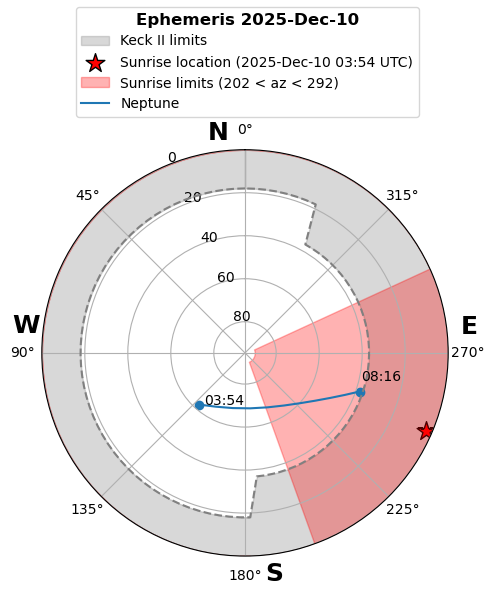

In [152]:
# Plot object trace, with Keck II and sunrise pointing limits

nep_az, nep_el, trace_times = grab_ss_trace('Neptune', keck, sunset_UTC, sunrise_UTC)

fig = make_azel_plot(sunset_UTC, sunset_az, sunrise_UTC, sunrise_az, 
                     nep_az, nep_el, trace_times, obj_label='Neptune')

plt.show()